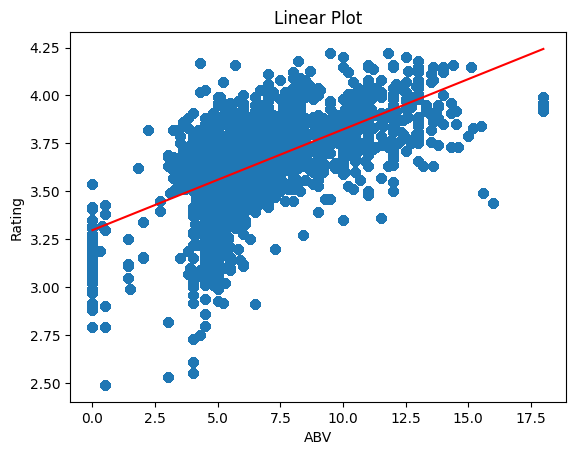

coef [0.05252502]
intercept 3.297556068248925
R²: 0.3553523322054539
Correlation: 0.5961143616836019
MeanSquaredError 0.034823673350044236
MeanAbsoluteError 0.1411273133067745
RootMeanSquaredError 0.18661102151278267


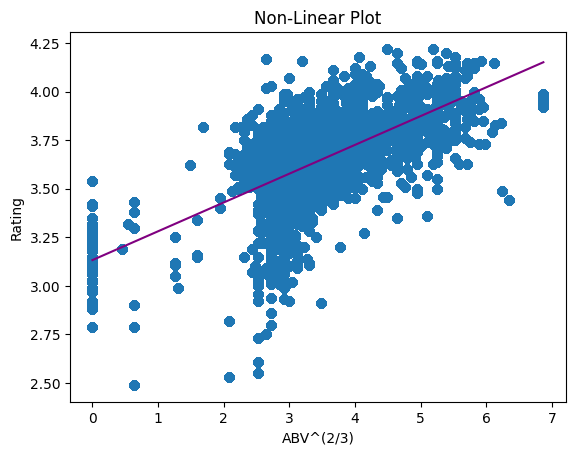

coef [0.14829971]
intercept 3.1328376098577557
R²: 0.37739776210214027
Correlation: 0.6143270807169154
MeanSquaredError 0.033632785849884723
MeanAbsoluteError 0.138581102436612
RootMeanSquaredError 0.18339243673032082


In [1]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

#import data from CSVs
data = []
files=["../2_Database/TopBeerData.csv","../2_Database/GoodBeerData.csv","../2_Database/RestBeerData.csv"]
for i in range (0,len(files)):
    with open(files[i],"r",encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader) # no to include the header
        for row in reader:
            data.append(row)

all_numeric_data = []
for j in range (0,len(data)):
    numeric_data = []
    for row in data[1:]:  # ignore heading
        numeric_data.append([
            float(row[6]),  # abv
            float(row[8])   #rating
        ])
    numeric_data = np.array(numeric_data)
    all_numeric_data.append(numeric_data)

combined = np.vstack(all_numeric_data)
x = combined[:, 0].reshape(-1, 1)
x2 = (x**(2/3)).reshape(-1,1)
y = combined[:, 1]

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)
corr = np.corrcoef(y, y_pred)
idx = np.argsort(x[:, 0])

plt.figure()
plt.scatter(x, y)
plt.xlabel("ABV")
plt.ylabel("Rating")
plt.title("Linear Plot")
plt.plot(x[idx], y_pred[idx],color="red")

plt.show()

print("coef",model.coef_)
print("intercept",model.intercept_)
print("R²:", r2)
print("Correlation:", corr[0,1])
print("MeanSquaredError",mean_squared_error(y,y_pred))
print("MeanAbsoluteError",mean_absolute_error(y,y_pred))
print("RootMeanSquaredError",np.sqrt(mean_squared_error(y,y_pred)))

model=0
model = LinearRegression()
model.fit(x2,y)
y2_pred = model.predict(x2)
r2_2 = r2_score(y, y2_pred)
corr2 = np.corrcoef(y, y2_pred)
idx2 = np.argsort(x2[:, 0])

plt.figure()
plt.scatter(x2, y)
plt.xlabel("ABV^(2/3)")
plt.ylabel("Rating")
plt.title("Non-Linear Plot")
plt.plot(x2[idx2], y2_pred[idx2],color="purple")

plt.show()
    
print("coef",model.coef_)
print("intercept",model.intercept_)
print("R²:", r2_2)
print("Correlation:", corr2[0,1])
print("MeanSquaredError",mean_squared_error(y,y2_pred))
print("MeanAbsoluteError",mean_absolute_error(y,y2_pred))
print("RootMeanSquaredError",np.sqrt(mean_squared_error(y,y2_pred)))

#no prediction since the corelation is not verys strong